# Quick analysis notebook
Run `finlit_structural.py` first (NFXP or NPL). Then execute the cells below.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# Choose which method you ran: 'nfxp' or 'npl'
method = 'npl'
ccp_path = Path(f'CCP_hat_{method}.npy')
policy_path = Path(f'policy_{method}.csv')
est_path = Path(f'finlit_estimates_{method}.csv')

CCP = np.load(ccp_path)
est = pd.read_csv(est_path)
policy = pd.read_csv(policy_path)
display(est)
print('CCP shape (S x D):', CCP.shape)


,parameter,estimate
0,sigma(fixed),2.000000e+00
1,F0,-5.085625e+12
2,phi,1.715016e+12


CCP shape (S x D): (225, 6)


Policy participation share: 1.0


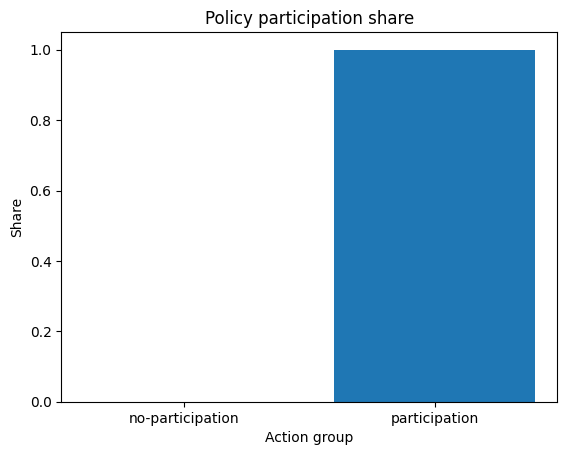

In [2]:
# Participation share under the policy (argmax over actions)
D = CCP.shape[1]
policy_idx = policy['policy_idx'].to_numpy()

# Action 0 is (d=0), others are (d=1,k)
share_participation = np.mean(policy_idx != 0)
print('Policy participation share:', share_participation)

plt.figure()
plt.bar(['no-participation','participation'], [1-share_participation, share_participation])
plt.title('Policy participation share')
plt.xlabel('Action group')
plt.ylabel('Share')
plt.show()


Average risky share under policy: 0.56


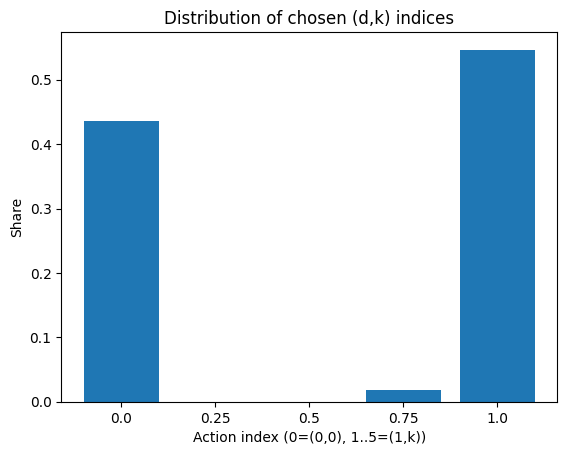

In [3]:
# Average risky share implied by the policy (treat index>0 mapped to k grid) 
risk_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
k_by_idx = [0.0] + risk_grid
avg_k = np.mean([k_by_idx[i] for i in policy_idx])
print('Average risky share under policy:', avg_k)

plt.figure()
plt.bar([str(k) for k in k_by_idx], [np.mean(policy_idx==i) for i in range(len(k_by_idx))])
plt.title('Distribution of chosen (d,k) indices')
plt.xlabel('Action index (0=(0,0), 1..5=(1,k))')
plt.ylabel('Share')
plt.show()
